# SARIMA & Seasonal Extensions

**Navigation**: [← Previous: ARMA & ARIMA](05_arma_arima.ipynb) | [Next: State-Space Models →](07_state_space.ipynb)

SARIMA extends ARIMA with seasonal differencing and seasonal AR/MA terms. The Box-Jenkins airline model ARIMA(0,1,1)(0,1,1)₁₂ remains the canonical benchmark.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

DATA_DIR = Path('data')
if not DATA_DIR.exists():
    DATA_DIR = Path('projects/time-series-analysis/data')

def load_series(name):
    """Load a bundled CSV as a DatetimeIndex Series."""
    df = pd.read_csv(DATA_DIR / name, parse_dates=['date'])
    return df.set_index('date')['value'].sort_index()

def load_air_passengers():
    path = DATA_DIR / 'air_passengers.csv'
    if path.exists():
        return load_series('air_passengers.csv')
    from statsmodels.datasets import get_rdataset
    air = get_rdataset('AirPassengers', 'datasets').data
    s = air['value']
    s.index = pd.date_range('1949-01', periods=len(s), freq='MS')
    return s

def load_milk():
    path = DATA_DIR / 'monthly_milk.csv'
    if path.exists():
        return load_series('monthly_milk.csv')
    url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-milk-production-pounds.csv'
    return pd.read_csv(url, index_col=0, parse_dates=True).squeeze()

def load_co2():
    from statsmodels.datasets import co2
    return co2.load().data.resample('MS').mean().ffill().squeeze()

def load_sunspots():
    from statsmodels.datasets import sunspots
    d = sunspots.load_pandas().data
    return d.set_index('YEAR')['SUNACTIVITY']

def load_retail():
    path = DATA_DIR / 'uk_retail_sales.csv'
    if path.exists():
        return load_series('uk_retail_sales.csv')
    raise FileNotFoundError('uk_retail_sales.csv not found in data/')
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from pmdarima import auto_arima

## The Airline Model

ARIMA$(0,1,1)(0,1,1)_{12}$: one regular and one seasonal difference, one MA and one seasonal MA.

In [2]:

air = load_air_passengers()
airline = SARIMAX(air, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False)
print(airline.summary().tables[1])
print(f'AIC={airline.aic:.1f}')


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3087      0.068     -4.507      0.000      -0.443      -0.174
ma.S.L12      -0.1075      0.091     -1.184      0.236      -0.285       0.070
sigma2       135.4237     15.443      8.769      0.000     105.156     165.691
AIC=1021.0


/Users/areeslindley/.pyenv/versions/3.13.0/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/areeslindley/.pyenv/versions/3.13.0/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


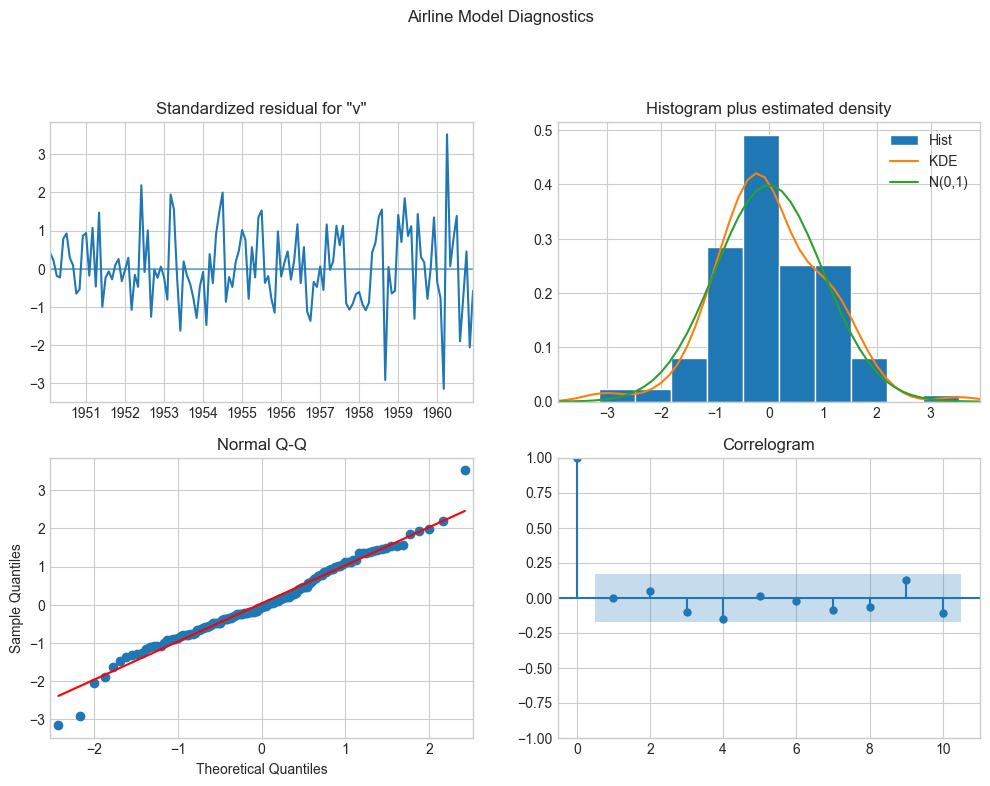

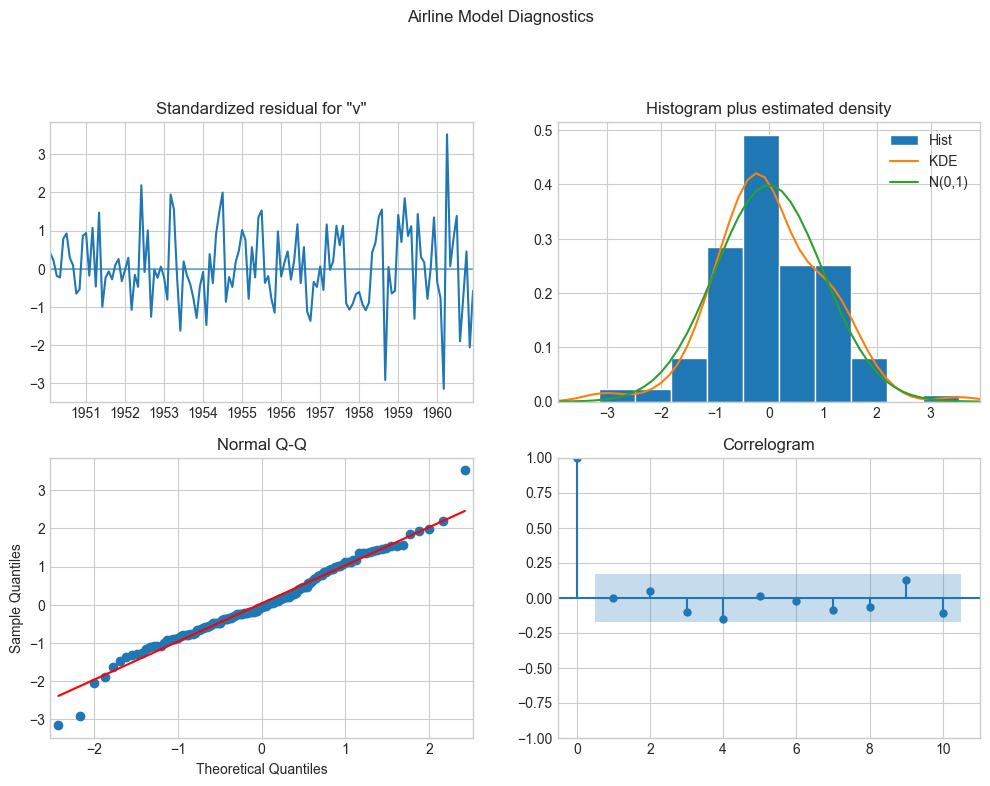

In [3]:

# Residual diagnostics
fig = airline.plot_diagnostics(figsize=(12, 8))
fig.suptitle('Airline Model Diagnostics', y=1.02)
fig


In [4]:

# auto-ARIMA with constrained search for CI speed
auto = auto_arima(
    air, seasonal=True, m=12, stepwise=True, suppress_warnings=True,
    max_p=2, max_q=2, max_P=1, max_Q=1, information_criterion='aic'
)
print(auto.summary())


                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -504.923
Date:                             Thu, 18 Jun 2026   AIC                           1017.847
Time:                                     17:48:45   BIC                           1029.348
Sample:                                 01-01-1949   HQIC                          1022.520
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5960      0.085      6.987      0.000       0.429       0.763
ar.L2          0.2143      

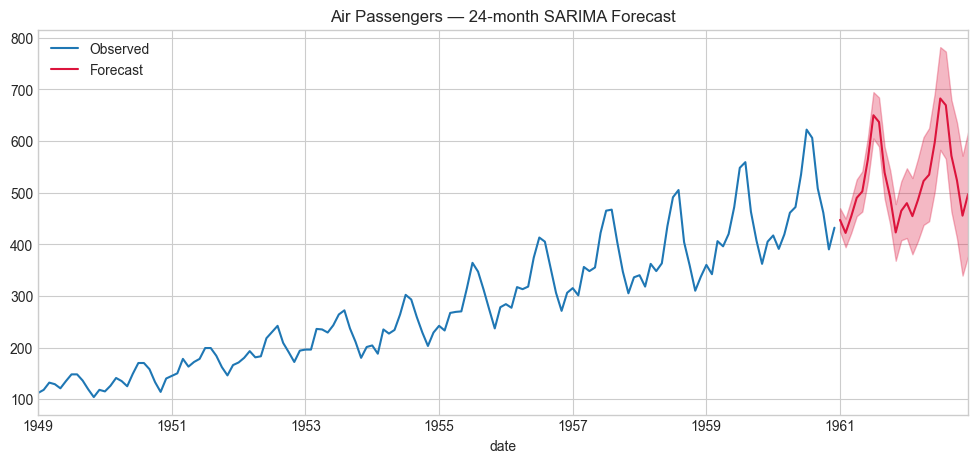

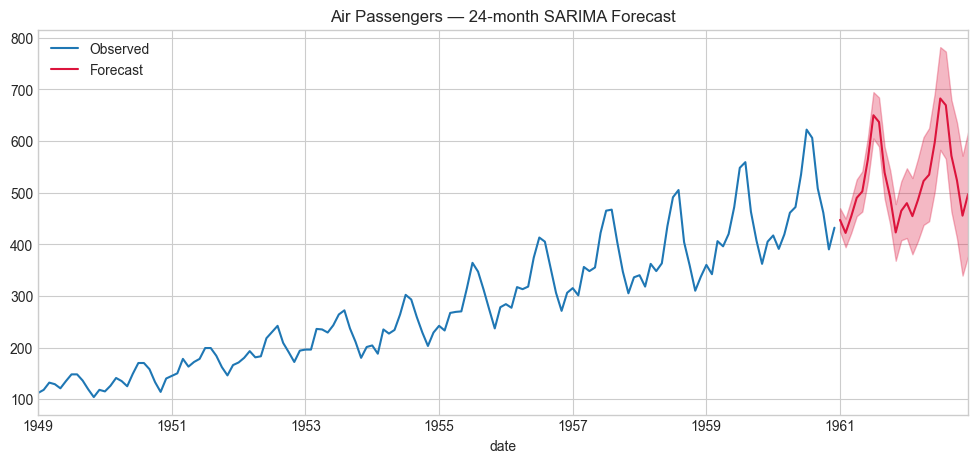

In [5]:

# 24-month forecast with intervals
forecast = airline.get_forecast(steps=24)
fc_mean = forecast.predicted_mean
fc_ci = forecast.conf_int()
fig, ax = plt.subplots(figsize=(12, 5))
air.plot(ax=ax, label='Observed')
fc_mean.plot(ax=ax, label='Forecast', color='crimson')
ax.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1], alpha=0.3, color='crimson')
ax.legend()
ax.set_title('Air Passengers — 24-month SARIMA Forecast')
fig


Production seasonal adjustment systems (X-13ARIMA-SEATS, TRAMO-SEATS, JDemetra+) implement these models at scale for official statistics — the airline model is their intellectual ancestor.

In [6]:

milk = load_milk()
milk_sarima = SARIMAX(milk, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(disp=False)
print(f'Milk SARIMA AIC={milk_sarima.aic:.1f}')


/Users/areeslindley/.pyenv/versions/3.13.0/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/areeslindley/.pyenv/versions/3.13.0/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Milk SARIMA AIC=980.7


## Key Takeaways

- **Seasonal differencing**: $(1-B^{12})y_t$ removes fixed monthly season; combine with regular differencing.
- **Airline model**: Still competitive after 50 years — parsimony beats complexity on short series.
- **auto-ARIMA**: Useful for exploration; always verify with residual diagnostics.
- **Production link**: ONS seasonal adjustment pipelines extend these ideas with regARIMA and calendar effects.

---

**Navigation**: [← Previous: ARMA & ARIMA](05_arma_arima.ipynb) | [Next: State-Space Models →](07_state_space.ipynb)
